# Image Classification with Convolutional Neural Networks
## Insect Classification — 9 Class Agricultural Pest Dataset
### 6CS012 — Artificial Intelligence and Machine Learning | Herald College, Kathmandu

---
**Dataset:** Insect Classification (train / test split)  
**Classes:** aphids, armyworm, beetle, bollworm, grasshopper, mites, mosquito, sawfly, stem_borer  
**Framework:** TensorFlow / Keras  
**Hardware:** Google Colab with GPU/TPU Acceleration  

---

## Step 0 — Mount Google Drive & Set Dataset Paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# ─────────────────────────────────────────────────────────────────────────────
# UPDATE THESE PATHS to match where the dataset lives on your Google Drive.
# If the folder is shared-with-you, it usually appears under MyDrive after
# you add a shortcut, OR directly under /content/drive/Shareddrives/
# ─────────────────────────────────────────────────────────────────────────────
BASE_DIR   = "/content/drive/MyDrive/Insect Classification"   # <── edit if needed
train_dir  = os.path.join(BASE_DIR, "train")
test_dir   = os.path.join(BASE_DIR, "test")

print("Train path exists:", os.path.exists(train_dir))
print("Test  path exists:", os.path.exists(test_dir))

Train path exists: True
Test  path exists: True


In [4]:
import shutil
from PIL import Image, UnidentifiedImageError

VALID_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')

def copy_clean_dataset(src_dir, dst_dir):
    """
    Copy only valid, decodable image files from src_dir to dst_dir.
    Skips any file that is not a valid image (corrupt, DS_Store, etc).
    """
    if os.path.exists(dst_dir):
        shutil.rmtree(dst_dir)
    os.makedirs(dst_dir)

    total_copied  = 0
    total_skipped = 0

    for cls in sorted(os.listdir(src_dir)):
        cls_src = os.path.join(src_dir, cls)
        if not os.path.isdir(cls_src):
            continue
        cls_dst = os.path.join(dst_dir, cls)
        os.makedirs(cls_dst, exist_ok=True)

        for fname in os.listdir(cls_src):
            if not fname.lower().endswith(VALID_EXTS):
                total_skipped += 1
                continue
            fpath = os.path.join(cls_src, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()          # check file integrity
                # Re-open to convert (verify() exhausts the file pointer)
                with Image.open(fpath) as img:
                    img.convert('RGB')    # ensure it is decodable as RGB
                shutil.copy2(fpath, os.path.join(cls_dst, fname))
                total_copied += 1
            except Exception:
                total_skipped += 1       # silently skip bad files

    print(f"  Copied  : {total_copied}  |  Skipped (bad/non-image): {total_skipped}")

print("Cleaning and copying TRAIN set...")
CLEAN_TRAIN_DIR = "/content/clean_insect/train"
copy_clean_dataset(train_dir, CLEAN_TRAIN_DIR)

print("Cleaning and copying TEST set...")
CLEAN_TEST_DIR = "/content/clean_insect/test"
copy_clean_dataset(test_dir, CLEAN_TEST_DIR)

print("Clean dataset ready.")
print("Train:", CLEAN_TRAIN_DIR)
print("Test :", CLEAN_TEST_DIR)

Cleaning and copying TRAIN set...
  Copied  : 2111  |  Skipped (bad/non-image): 121
Cleaning and copying TEST set...
  Copied  : 384  |  Skipped (bad/non-image): 0
Clean dataset ready.
Train: /content/clean_insect/train
Test : /content/clean_insect/test


## Step 1 — Imports & GPU Configuration

In [5]:
import numpy as np
import random
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [6]:
# Enable GPU memory growth to avoid OOM errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU(s) available: {len(gpus)}")
    print(tf.test.gpu_device_name())
else:
    print("No GPU found — running on CPU. Consider switching to GPU runtime in Colab.")

# Mixed precision for faster training on modern GPUs (optional — comment out if issues arise)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Compute policy:", mixed_precision.global_policy().name)

GPU(s) available: 1
/device:GPU:0
Compute policy: mixed_float16


---
# Part A — Data Understanding, Analysis, Visualization and Cleaning

Before building any model we thoroughly understand the dataset:
- What it represents
- Total image count and class distribution
- Integrity check (corrupted images)
- Visual samples per class
- Preprocessing choices

**Note:** The dataset has only `train/` and `test/` folders (no separate `val/` folder).  
We create a validation split (20%) from the training data using `validation_split` in Keras.

In [7]:
def get_class_names(directory):
    """List and print class subdirectories inside a split folder."""
    class_names = sorted([
        d for d in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, d))
    ])
    if not class_names:
        print("No class directories found!")
    else:
        print(f"Found {len(class_names)} classes: {class_names}")
    return class_names

print("=== TRAIN DIRECTORY ===")
class_names = get_class_names(train_dir)

print("\n=== TEST DIRECTORY ===")
get_class_names(test_dir)

=== TRAIN DIRECTORY ===
Found 9 classes: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']

=== TEST DIRECTORY ===
Found 9 classes: ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


['aphids',
 'armyworm',
 'beetle',
 'bollworm',
 'grasshopper',
 'mites',
 'mosquito',
 'sawfly',
 'stem_borer']

In [8]:
def check_corrupt_images(directory, label=""):
    """Scan every image in directory and report any corrupted files."""
    corrupted = []
    class_names = sorted(os.listdir(directory))
    for cls in class_names:
        cls_path = os.path.join(directory, cls)
        if not os.path.isdir(cls_path):
            continue
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted.append(img_path)
    if corrupted:
        print(f"[{label}] {len(corrupted)} corrupted image(s) found:")
        for p in corrupted:
            print(" ", p)
    else:
        print(f"[{label}] No corrupted images found. ✔")

check_corrupt_images(train_dir, "TRAIN")
check_corrupt_images(test_dir,  "TEST")

[TRAIN] 121 corrupted image(s) found:
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_22 - Copy (2).jpg
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_30 - Copy (4).jpg
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_33 - Copy (3).jpg
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_9.jpg
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_15 - Copy (3).jpg
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_72.jpg
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_52 - Copy (2).jpg
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_10 - Copy (4).jpg
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_32 - Copy (2).jpg
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_61.jpg
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_79 - Copy.jpg
  /content/drive/MyDrive/Insect Classification/train/aphids/jpg_24.jpg
  /content/drive/MyDrive/In

In [9]:
def count_class(directory, label=""):
    """Count images per class and print a formatted table."""
    class_names = sorted(os.listdir(directory))
    class_counts = {}
    total = 0
    for cls in class_names:
        cls_path = os.path.join(directory, cls)
        if not os.path.isdir(cls_path):
            continue
        imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[cls] = len(imgs)
        total += len(imgs)

    print(f"\n{'='*50}")
    print(f" Class Distribution — {label}")
    print(f"{'='*50}")
    print(f"{'Class':<22} {'Count':>8} {'% of Total':>10}")
    print(f"{'-'*50}")
    for cls, cnt in class_counts.items():
        print(f"{cls:<22} {cnt:>8} {cnt/total*100:>9.1f}%")
    print(f"{'-'*50}")
    print(f"{'TOTAL':<22} {total:>8}")
    print(f"{'='*50}")
    return class_counts, total

train_counts, train_total = count_class(train_dir, "TRAIN")
test_counts,  test_total  = count_class(test_dir,  "TEST")


 Class Distribution — TRAIN
Class                     Count % of Total
--------------------------------------------------
aphids                      266      11.9%
armyworm                    223      10.0%
beetle                      291      13.0%
bollworm                    245      11.0%
grasshopper                 277      12.4%
mites                       254      11.4%
mosquito                    295      13.2%
sawfly                      200       9.0%
stem_borer                  181       8.1%
--------------------------------------------------
TOTAL                      2232

 Class Distribution — TEST
Class                     Count % of Total
--------------------------------------------------
aphids                       44      11.5%
armyworm                     43      11.2%
beetle                       50      13.0%
bollworm                     36       9.4%
grasshopper                  46      12.0%
mites                        42      10.9%
mosquito                   

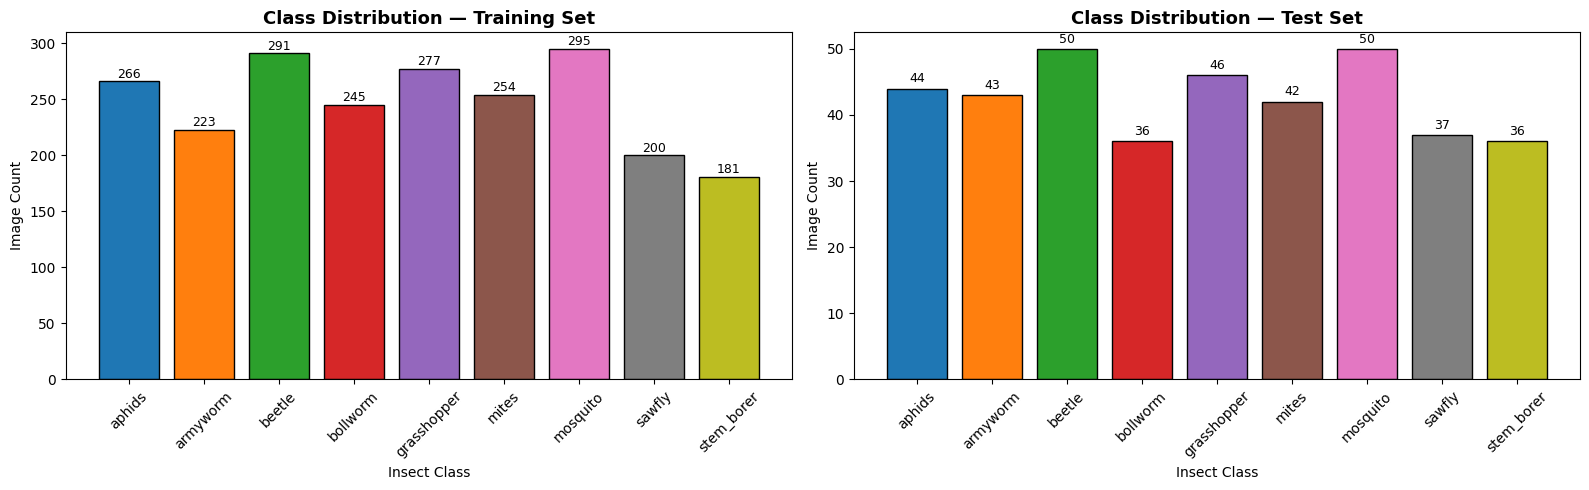


Total training images : 2232
Total test images     : 384
Validation split      : 20% carved from training data (via Keras validation_split)


In [10]:
# ── Bar chart: class distribution in train set ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, counts, title in zip(
        axes,
        [train_counts, test_counts],
        ["Training Set", "Test Set"]):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=plt.cm.tab10(range(len(counts))), edgecolor='black')
    ax.set_title(f"Class Distribution — {title}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Insect Class")
    ax.set_ylabel("Image Count")
    ax.tick_params(axis='x', rotation=45)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print(f"\nTotal training images : {train_total}")
print(f"Total test images     : {test_total}")
print("Validation split      : 20% carved from training data (via Keras validation_split)")

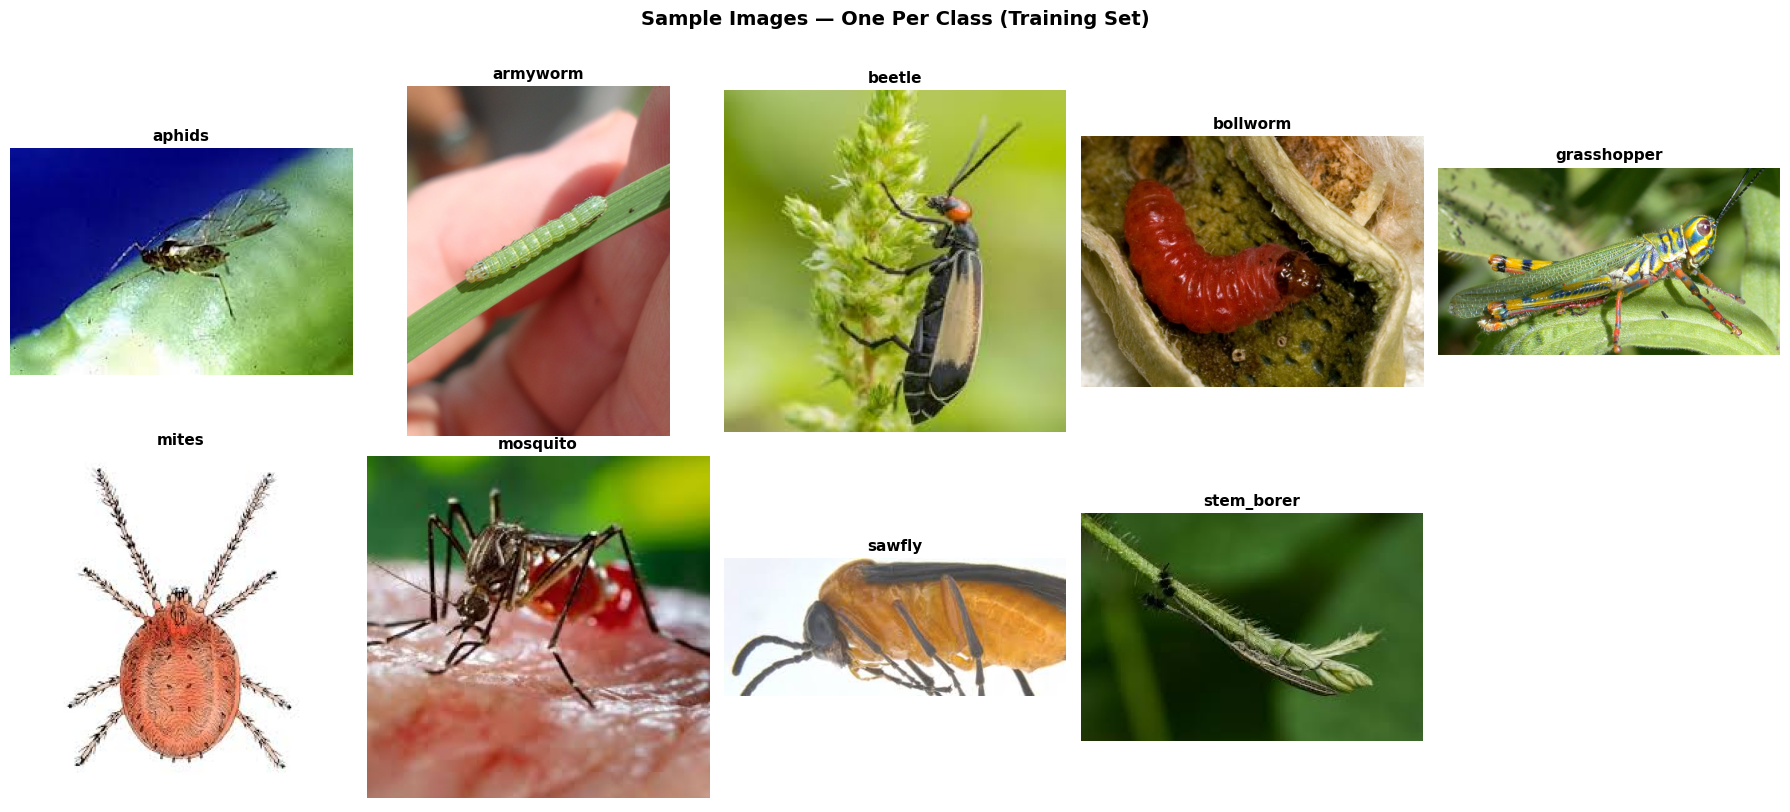

In [11]:
# ── One sample image per class ────────────────────────────────────────────────
selected_images, selected_labels = [], []
for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    if not os.path.isdir(cls_path):
        continue
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if imgs:
        selected_images.append(os.path.join(cls_path, random.choice(imgs)))
        selected_labels.append(cls)

n = len(selected_images)
cols = 5
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flat

for i, ax in enumerate(axes):
    if i < n:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i], fontsize=11, fontweight='bold')
        ax.axis("off")
    else:
        ax.axis("off")

fig.suptitle("Sample Images — One Per Class (Training Set)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Preprocessing Strategy

| Step | Detail |
|------|--------|
| **Resize** | All images → 224×224 px (standard CNN input) |
| **Normalization** | Pixel values rescaled from [0, 255] → [0, 1] via a `Rescaling(1/255)` layer |
| **Validation Split** | 20% of training images reserved for validation (`validation_split=0.2`) |
| **Augmentation** | Applied to the training set only: horizontal flip, rotation ±10°, zoom ±10%, contrast ±10% |
| **Class Weights** | Computed via `sklearn` to compensate for any class imbalance |
| **Dataset Caching** | `.cache().prefetch(AUTOTUNE)` for CPU/IO bottleneck elimination |

In [12]:
IMG_HEIGHT  = 128
IMG_WIDTH   = 128
BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE

# ── Training split (80%) ──────────────────────────────────────────────────────
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    CLEAN_TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='bilinear',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# ── Validation split (20%) ────────────────────────────────────────────────────
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    CLEAN_TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='bilinear',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ── Test set ──────────────────────────────────────────────────────────────────
test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    CLEAN_TEST_DIR,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

NUM_CLASSES = len(train_ds_raw.class_names)
CLASS_NAMES = train_ds_raw.class_names

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Training batches  : {len(train_ds_raw)}")
print(f"Validation batches: {len(val_ds_raw)}")
print(f"Test batches      : {len(test_ds_raw)}")

Found 2111 files belonging to 9 classes.
Using 1689 files for training.
Found 2111 files belonging to 9 classes.
Using 422 files for validation.
Found 384 files belonging to 9 classes.
Classes (9): ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']
Training batches  : 53
Validation batches: 14
Test batches      : 12


In [13]:
# Compute class weights directly from folder counts (avoids corrupt-file errors)
VALID_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')

class_counts_for_weights = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        n = sum(1 for f in os.listdir(cls_path)
                if f.lower().endswith(VALID_EXTS))
        class_counts_for_weights[cls] = n

# Build label array the same way Keras infers labels (alphabetical class order)
all_labels = []
for idx, cls in enumerate(CLASS_NAMES):
    all_labels.extend([idx] * class_counts_for_weights[cls])

import numpy as np
from sklearn.utils.class_weight import compute_class_weight
all_labels = np.array(all_labels)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
CLASS_WEIGHTS = dict(enumerate(class_weights_arr))

print("Class weights:")
for i, cw in CLASS_WEIGHTS.items():
    print(f"  {CLASS_NAMES[i]:<22} count={class_counts_for_weights[CLASS_NAMES[i]]:>4}  weight={cw:.4f}")

Class weights:
  aphids                 count= 266  weight=0.9323
  armyworm               count= 223  weight=1.1121
  beetle                 count= 291  weight=0.8522
  bollworm               count= 245  weight=1.0122
  grasshopper            count= 277  weight=0.8953
  mites                  count= 254  weight=0.9764
  mosquito               count= 295  weight=0.8407
  sawfly                 count= 200  weight=1.2400
  stem_borer             count= 181  weight=1.3702


### Data Augmentation

Augmentation is applied **only to the training set** at the pipeline level, so validation and test images are never modified.

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

# Build final pipeline functions
def make_train_pipeline(ds):
    return (
        ds
        .map(lambda x, y: (data_augmentation(x, training=True), y),
             num_parallel_calls=AUTOTUNE)
        .cache()
        .prefetch(AUTOTUNE)
    )

def make_eval_pipeline(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = make_train_pipeline(train_ds_raw)
val_ds   = make_eval_pipeline(val_ds_raw)
test_ds  = make_eval_pipeline(test_ds_raw)

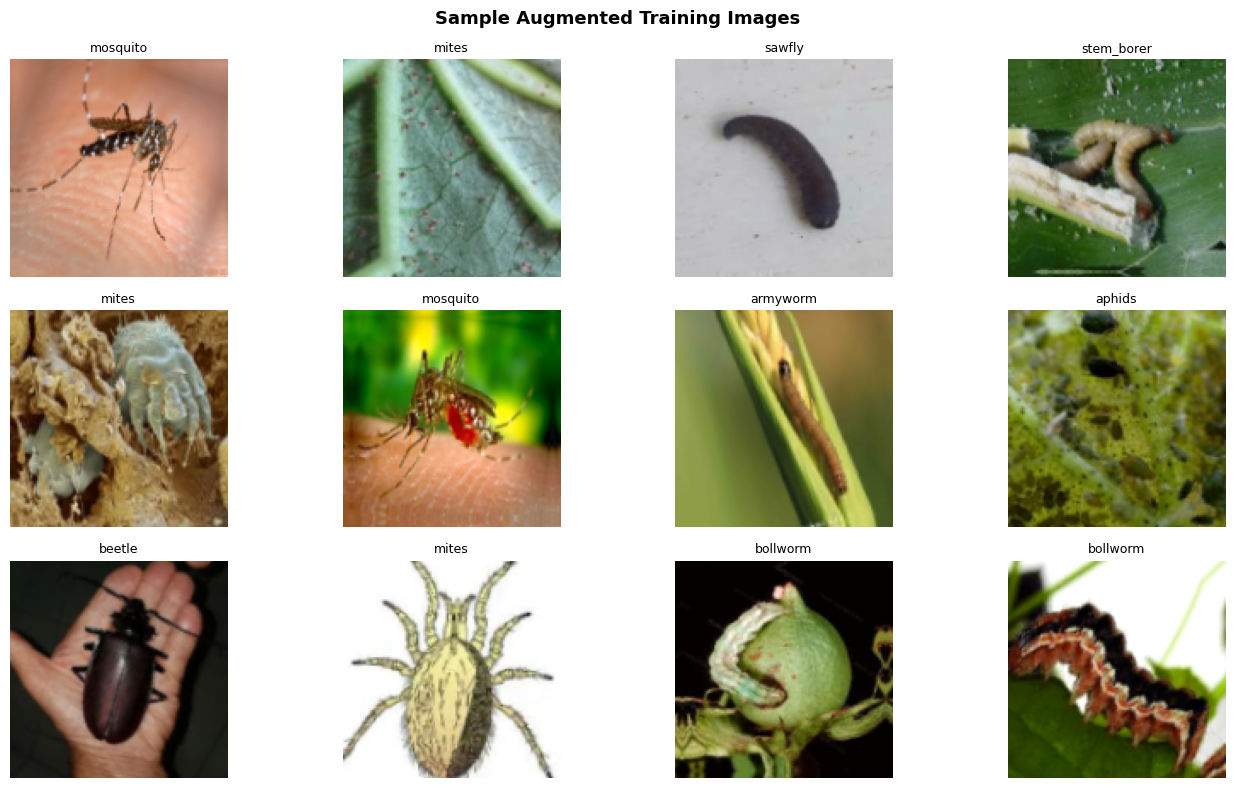

In [15]:
# Visualise augmented training images
images, labels = next(iter(train_ds))

plt.figure(figsize=(14, 8))
for i in range(min(12, images.shape[0])):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(CLASS_NAMES[labels[i]], fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Augmented Training Images", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part A — Section 1: Baseline CNN Model (Trained from Scratch)

**Architecture:** 3 Conv+Pool blocks → 3 Dense (FCN) layers → Softmax output  
**Optimizer:** Adam | **Loss:** Sparse Categorical Cross-Entropy

In [18]:
def build_baseline_model(num_classes):
    model = keras.Sequential([
        layers.Input(shape=(128, 128, 3)),
        layers.Rescaling(1. / 255),          # Normalize to [0, 1]

        # ── Convolutional Block 1 ──────────────────────────────────────
        layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      name='conv1'),          # 32 filters, 3×3 kernel
        layers.MaxPooling2D((2, 2), name='pool1'),

        # ── Convolutional Block 2 ──────────────────────────────────────
        layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      name='conv2'),          # 64 filters, 3×3 kernel
        layers.MaxPooling2D((2, 2), name='pool2'),

        # ── Convolutional Block 3 ──────────────────────────────────────
        layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                      name='conv3'),          # 128 filters, 3×3 kernel
        layers.MaxPooling2D((2, 2), name='pool3'),

        # ── Fully Connected Layers ─────────────────────────────────────
        layers.Flatten(),
        layers.Dense(128, activation='relu', name='fc1'),
        layers.Dense(64,  activation='relu', name='fc2'),
        layers.Dense(32,  activation='relu', name='fc3'),

        # ── Output Layer ───────────────────────────────────────────────
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name="Baseline_CNN")
    return model

baseline_model = build_baseline_model(NUM_CLASSES)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,298,313 (16.40 MB)

 Trainable params: 4,298,313 (16.40 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

print("Starting Baseline CNN training...")
baseline_start = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

BASELINE_TRAIN_TIME = time.time() - baseline_start
print(f"\nBaseline training time: {BASELINE_TRAIN_TIME:.1f} s ({BASELINE_TRAIN_TIME/60:.1f} min)")

Starting Baseline CNN training...
Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 347ms/step - accuracy: 0.1735 - loss: 2.1324 - val_accuracy: 0.0118 - val_loss: 2.5306 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.2818 - loss: 1.9359 - val_accuracy: 0.1825 - val_loss: 2.2133 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3937 - loss: 1.7477 - val_accuracy: 0.2227 - val_loss: 2.1024 - learning_rate: 0.0010
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4328 - loss: 1.5465 - val_accuracy: 0.2512 - val_loss: 2.1030 - learning_rate: 0.0010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5234 - loss: 1.3555 - val_accuracy: 0.2322 - val_loss: 2.1386 - learning_rate: 0.0010
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6134 - loss: 1.0864 - val_accuracy: 0.3673 - val_loss: 2.1135 - learning_rate: 0.0010
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accu

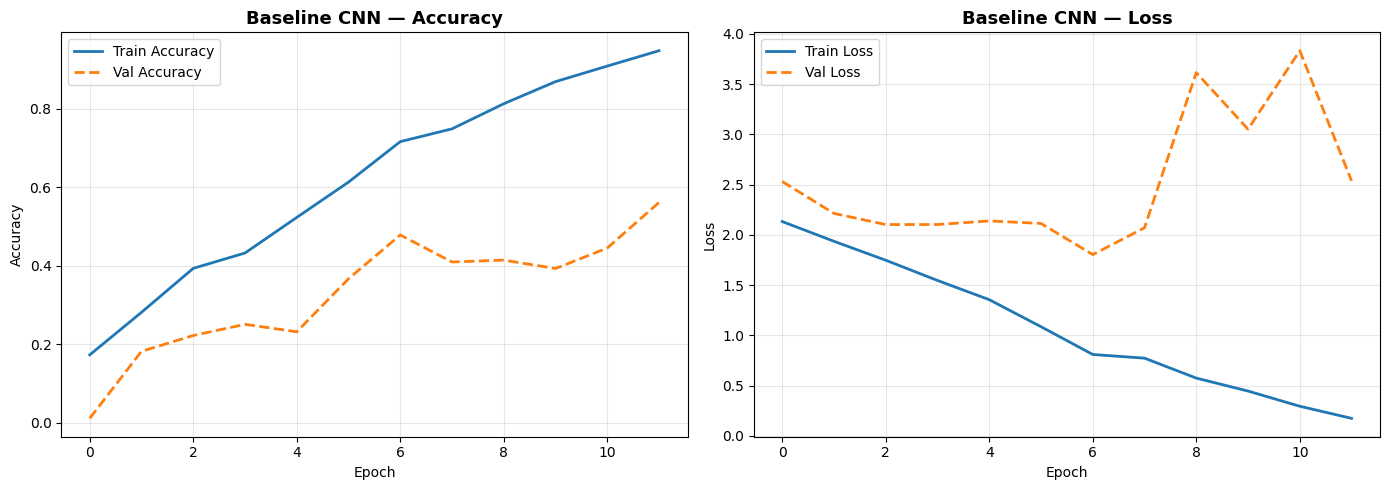

In [20]:
def plot_history(history, title="Model"):
    """Plot training vs validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, linestyle='--')
    axes[0].set_title(f"{title} — Accuracy", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
    axes[1].set_title(f"{title} — Loss", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline CNN")


  Evaluation Results — Baseline CNN
              precision    recall  f1-score   support

      aphids       0.65      0.25      0.36        44
    armyworm       0.34      0.51      0.41        43
      beetle       0.65      0.80      0.71        50
    bollworm       0.61      0.31      0.41        36
 grasshopper       0.44      0.70      0.54        46
       mites       0.61      0.52      0.56        42
    mosquito       0.90      0.76      0.83        50
      sawfly       0.45      0.51      0.48        37
  stem_borer       0.47      0.39      0.42        36

    accuracy                           0.54       384
   macro avg       0.57      0.53      0.53       384
weighted avg       0.58      0.54      0.54       384



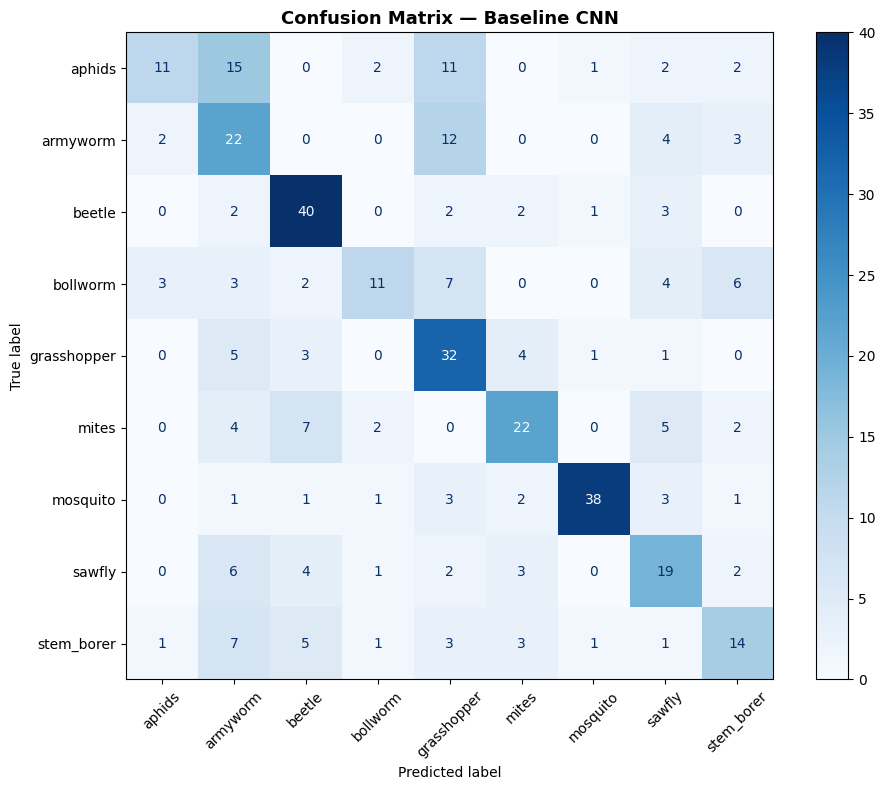

In [21]:
def evaluate_model(model, test_dataset, class_names, model_name="Model"):
    """Full evaluation: accuracy, classification report, and confusion matrix."""
    y_pred_probs = model.predict(test_dataset, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.concatenate([y.numpy() for _, y in test_dataset])

    print(f"\n{'='*60}")
    print(f"  Evaluation Results — {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return y_true, y_pred

y_true_b, y_pred_b = evaluate_model(baseline_model, test_ds, CLASS_NAMES, "Baseline CNN")

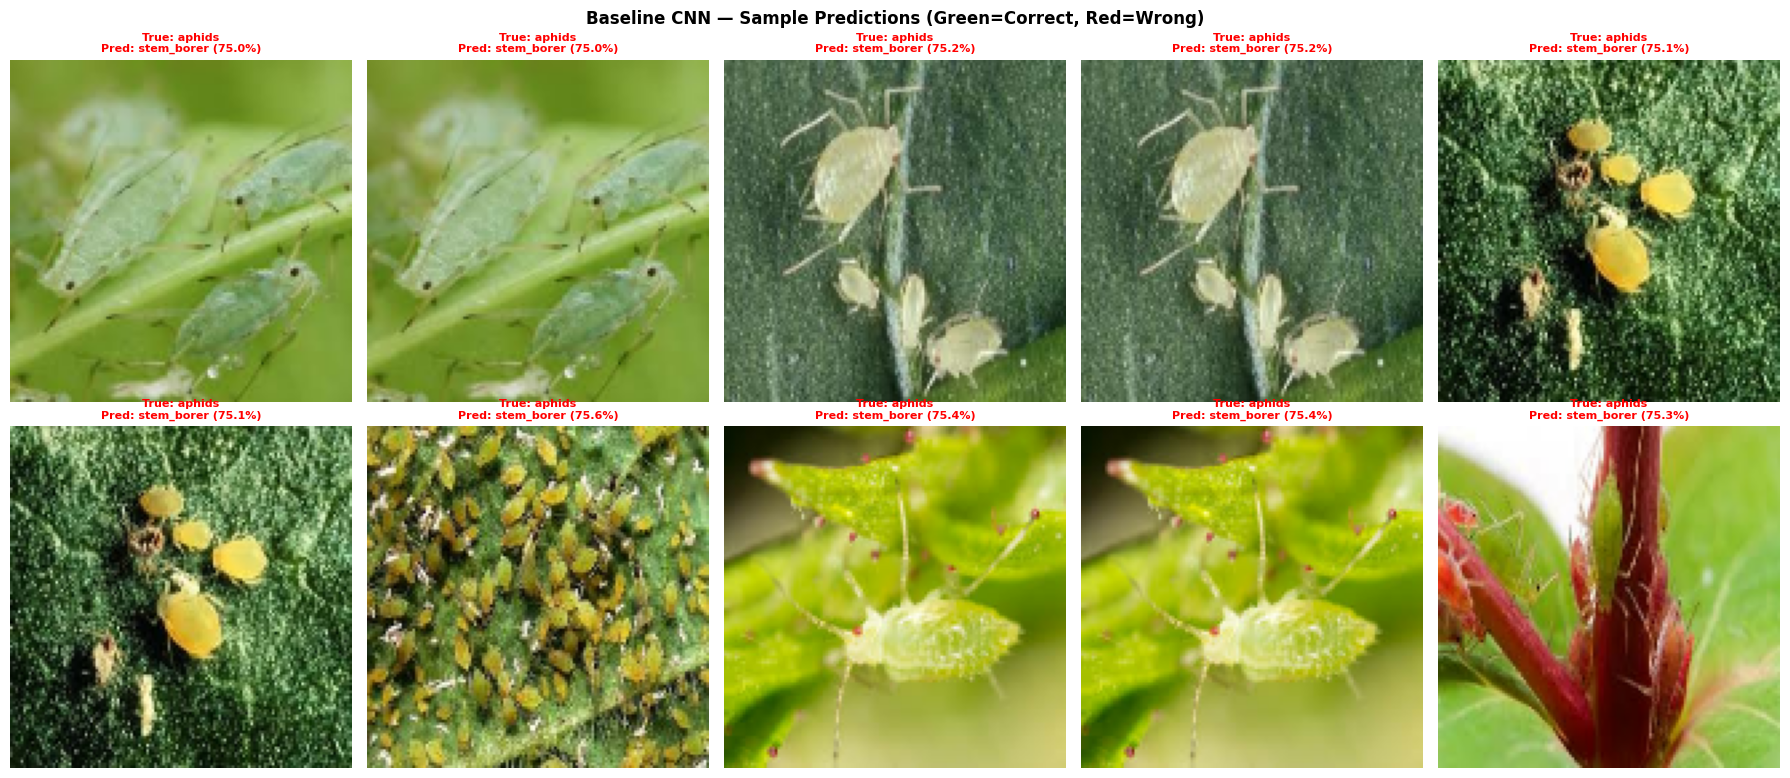

In [22]:
# ── Sample inference on test images ──────────────────────────────────────────
sample_images, sample_labels = next(iter(test_ds_raw))

preds = baseline_model.predict(sample_images / 255.0, verbose=0)
pred_classes = np.argmax(preds, axis=1)
confidences  = np.max(preds, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    if i >= sample_images.shape[0]:
        ax.axis('off')
        continue
    ax.imshow(sample_images[i].numpy().astype('uint8'))
    true_cls = CLASS_NAMES[sample_labels[i]]
    pred_cls = CLASS_NAMES[pred_classes[i]]
    color = 'green' if true_cls == pred_cls else 'red'
    ax.set_title(f"True: {true_cls}\nPred: {pred_cls} ({confidences[i]*100:.1f}%)",
                 color=color, fontsize=8, fontweight='bold')
    ax.axis('off')

plt.suptitle("Baseline CNN — Sample Predictions (Green=Correct, Red=Wrong)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part A — Section 2: Deeper CNN Architecture with Regularization

**Architecture:** 6 Conv+BN+Pool blocks (double the baseline) → GlobalAveragePooling → Dense + Dropout layers  
**Regularization:** BatchNormalization + Dropout (0.3)  
**Optimizer:** Adam (lr=1e-4)

In [23]:
def build_deeper_model(num_classes):
    model = keras.Sequential([
        layers.Input(shape=(128, 128, 3)),
        layers.Rescaling(1. / 255),

        # ── Block 1 ────────────────────────────────────────────────────
        layers.Conv2D(32, (3, 3), padding='same', name='conv1'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Block 2 ────────────────────────────────────────────────────
        layers.Conv2D(64, (3, 3), padding='same', name='conv2'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Block 3 ────────────────────────────────────────────────────
        layers.Conv2D(128, (3, 3), padding='same', name='conv3'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Block 4 ────────────────────────────────────────────────────
        layers.Conv2D(256, (3, 3), padding='same', name='conv4'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Block 5 ────────────────────────────────────────────────────
        layers.Conv2D(512, (3, 3), padding='same', name='conv5'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Block 6 ────────────────────────────────────────────────────
        layers.Conv2D(512, (3, 3), padding='same', name='conv6'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Classifier Head ────────────────────────────────────────────
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu', name='fc1'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu', name='fc2'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu',  name='fc3'),

        layers.Dense(num_classes, activation='softmax', name='output')
    ], name="Deeper_CNN")
    return model

deeper_model = build_deeper_model(NUM_CLASSES)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,107,465 (15.67 MB)

 Trainable params: 4,104,457 (15.66 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [24]:
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_d = EarlyStopping(monitor='val_loss', patience=10,
                              restore_best_weights=True, verbose=1)
reduce_lr_d  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                  patience=5, min_lr=1e-7, verbose=1)

print("Starting Deeper CNN training...")
deeper_start = time.time()

deeper_history = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop_d, reduce_lr_d],
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

DEEPER_TRAIN_TIME = time.time() - deeper_start
print(f"\nDeeper CNN training time: {DEEPER_TRAIN_TIME:.1f} s ({DEEPER_TRAIN_TIME/60:.1f} min)")

Starting Deeper CNN training...
Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 371ms/step - accuracy: 0.2049 - loss: 2.1956 - val_accuracy: 0.1611 - val_loss: 2.1555 - learning_rate: 1.0000e-04
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3079 - loss: 1.9145 - val_accuracy: 0.1611 - val_loss: 2.1262 - learning_rate: 1.0000e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3996 - loss: 1.7391 - val_accuracy: 0.1066 - val_loss: 2.0683 - learning_rate: 1.0000e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4742 - loss: 1.5570 - val_accuracy: 0.1611 - val_loss: 2.2535 - learning_rate: 1.0000e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5400 - loss: 1.3849 - val_accuracy: 0.1469 - val_loss: 1.9744 - learning_rate: 1.0000e-04
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6240 - loss: 1.1734 - val_accuracy: 0.1588 - val_loss: 2.0963 - learning_rate: 1.0000e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━

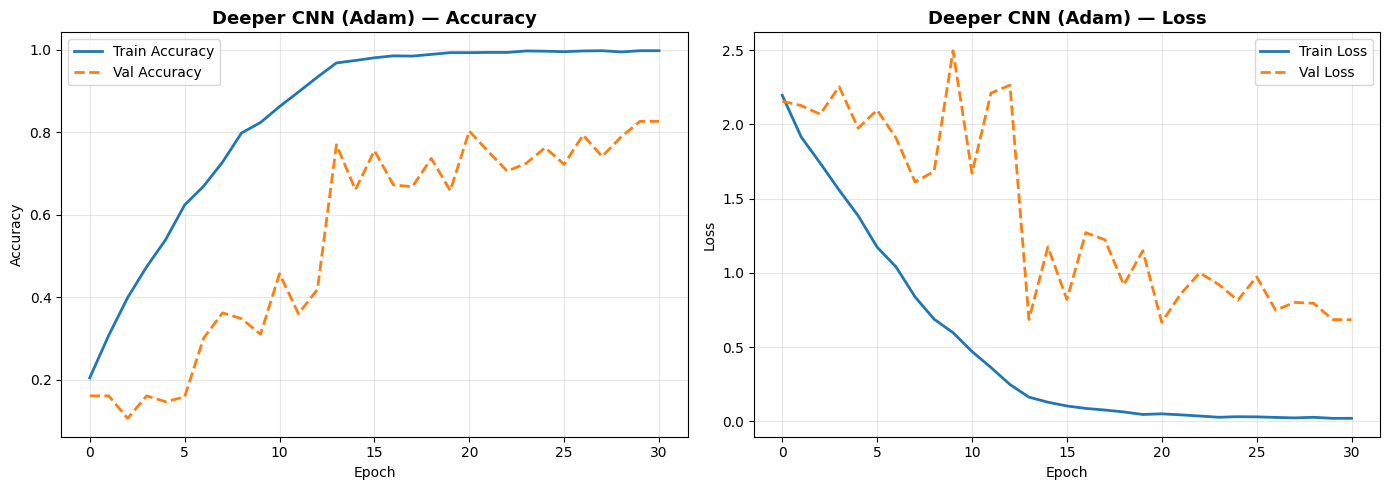

In [25]:
plot_history(deeper_history, "Deeper CNN (Adam)")


  Evaluation Results — Deeper CNN
              precision    recall  f1-score   support

      aphids       0.75      0.95      0.84        44
    armyworm       1.00      0.67      0.81        43
      beetle       0.98      0.94      0.96        50
    bollworm       0.91      0.89      0.90        36
 grasshopper       0.69      0.93      0.80        46
       mites       0.95      0.88      0.91        42
    mosquito       0.89      0.98      0.93        50
      sawfly       0.93      0.68      0.78        37
  stem_borer       0.88      0.81      0.84        36

    accuracy                           0.87       384
   macro avg       0.89      0.86      0.86       384
weighted avg       0.89      0.87      0.87       384



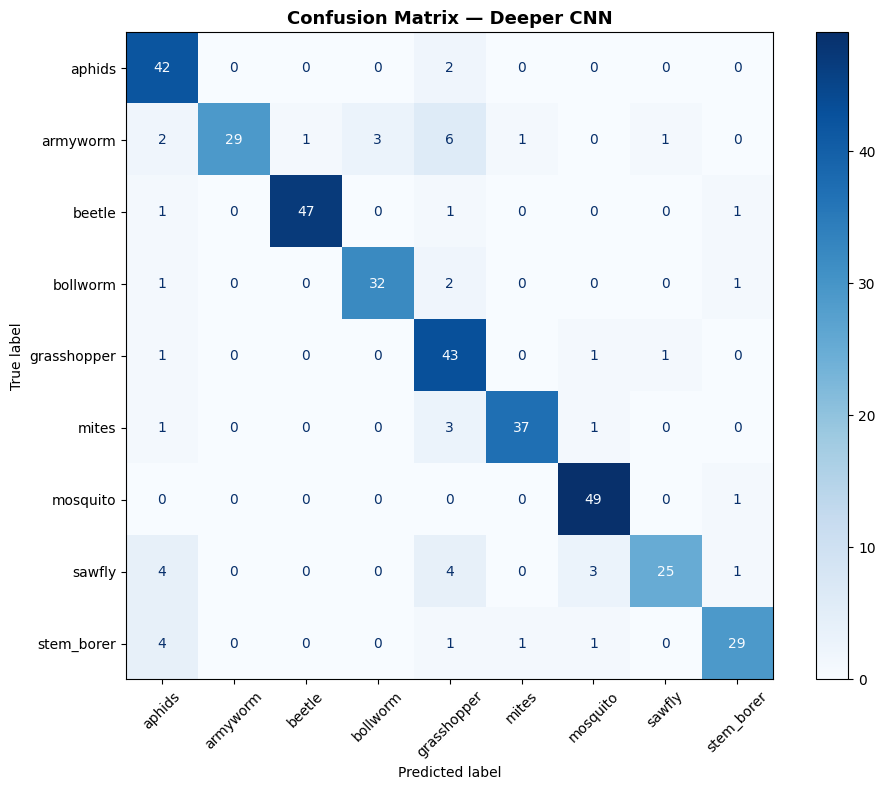

In [26]:
y_true_d, y_pred_d = evaluate_model(deeper_model, test_ds, CLASS_NAMES, "Deeper CNN")

---
# Part A — Section 3: Experimentation & Comparative Analysis

## 3a. Optimizer Comparison — SGD vs Adam (Deeper Architecture)

In [27]:
deeper_model_sgd = build_deeper_model(NUM_CLASSES)

deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9, nesterov=True),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_sgd = EarlyStopping(monitor='val_loss', patience=10,
                                restore_best_weights=True, verbose=1)
reduce_lr_sgd  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=5, min_lr=1e-6, verbose=1)

print("Starting Deeper CNN training with SGD...")
sgd_start = time.time()

sgd_history = deeper_model_sgd.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop_sgd, reduce_lr_sgd],
    class_weight=CLASS_WEIGHTS,
    verbose=1
)

SGD_TRAIN_TIME = time.time() - sgd_start
print(f"\nSGD training time: {SGD_TRAIN_TIME:.1f} s ({SGD_TRAIN_TIME/60:.1f} min)")

Starting Deeper CNN training with SGD...
Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 228ms/step - accuracy: 0.2202 - loss: 2.1537 - val_accuracy: 0.0000e+00 - val_loss: 2.1646 - learning_rate: 0.0100
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3091 - loss: 1.9340 - val_accuracy: 0.0000e+00 - val_loss: 2.2740 - learning_rate: 0.0100
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3795 - loss: 1.7791 - val_accuracy: 0.0000e+00 - val_loss: 2.2866 - learning_rate: 0.0100
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4298 - loss: 1.6378 - val_accuracy: 0.1066 - val_loss: 2.4000 - learning_rate: 0.0100
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4731 - loss: 1.4882 - val_accuracy: 0.2370 - val_loss: 2.0097 - learning_rate: 0.0100
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5287 - loss: 1.3731 - val_accuracy: 0.3791 - val_loss: 1.9146 - learning_rate: 0.0100
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1

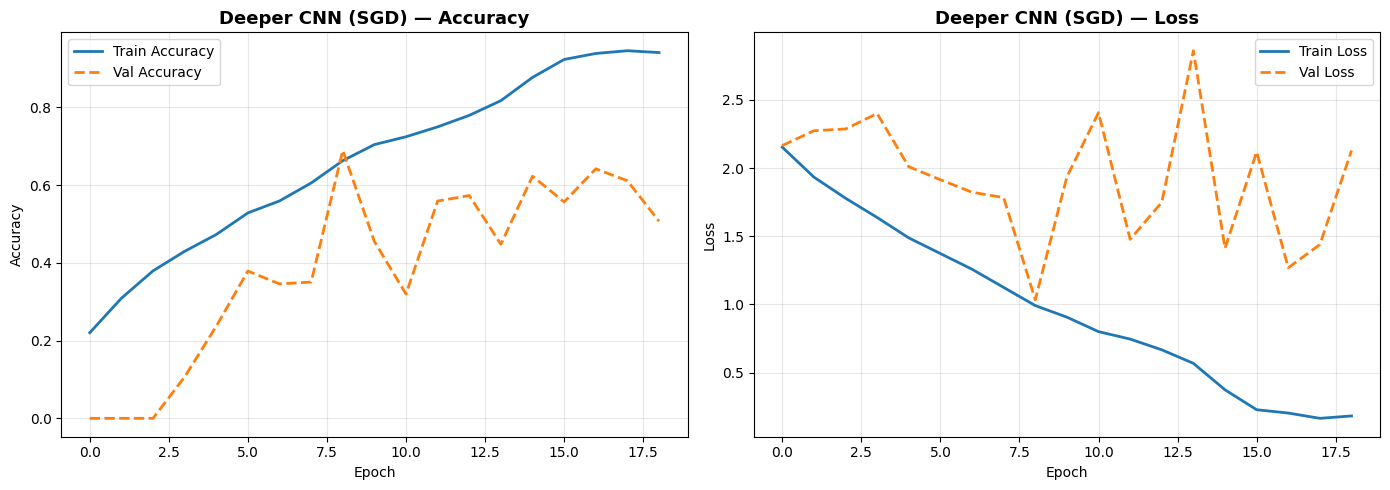


  Evaluation Results — Deeper CNN (SGD)
              precision    recall  f1-score   support

      aphids       0.85      0.39      0.53        44
    armyworm       0.67      0.19      0.29        43
      beetle       0.95      0.82      0.88        50
    bollworm       0.74      0.56      0.63        36
 grasshopper       0.41      0.72      0.52        46
       mites       0.64      0.33      0.44        42
    mosquito       0.64      0.94      0.76        50
      sawfly       0.35      0.76      0.48        37
  stem_borer       0.50      0.36      0.42        36

    accuracy                           0.58       384
   macro avg       0.64      0.56      0.55       384
weighted avg       0.65      0.58      0.56       384



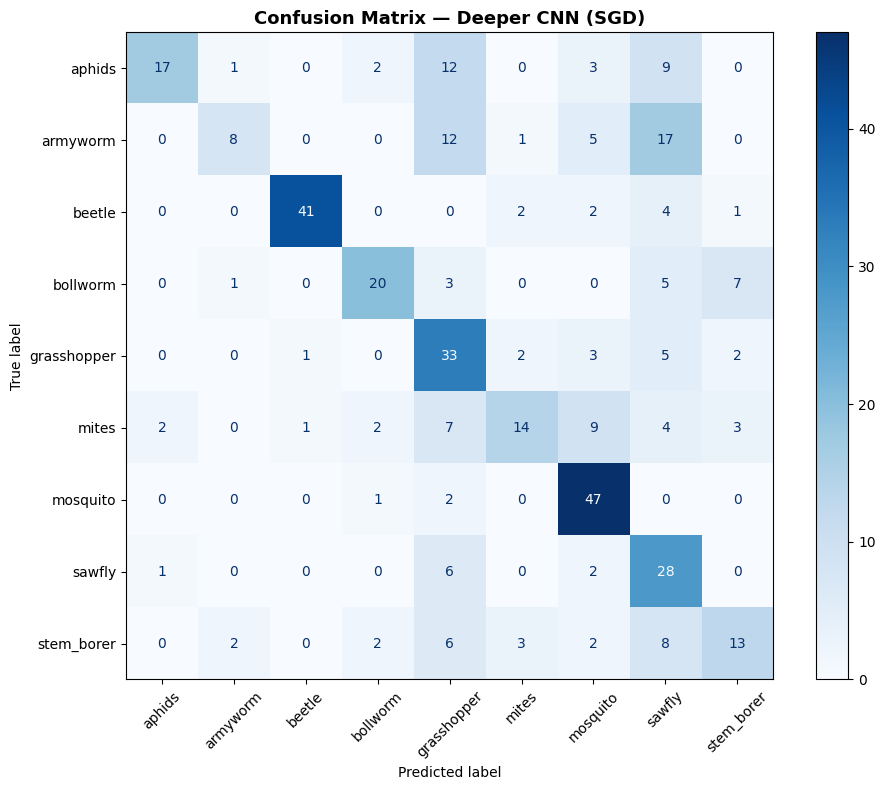

In [28]:
plot_history(sgd_history, "Deeper CNN (SGD)")
y_true_sgd, y_pred_sgd = evaluate_model(deeper_model_sgd, test_ds, CLASS_NAMES, "Deeper CNN (SGD)")

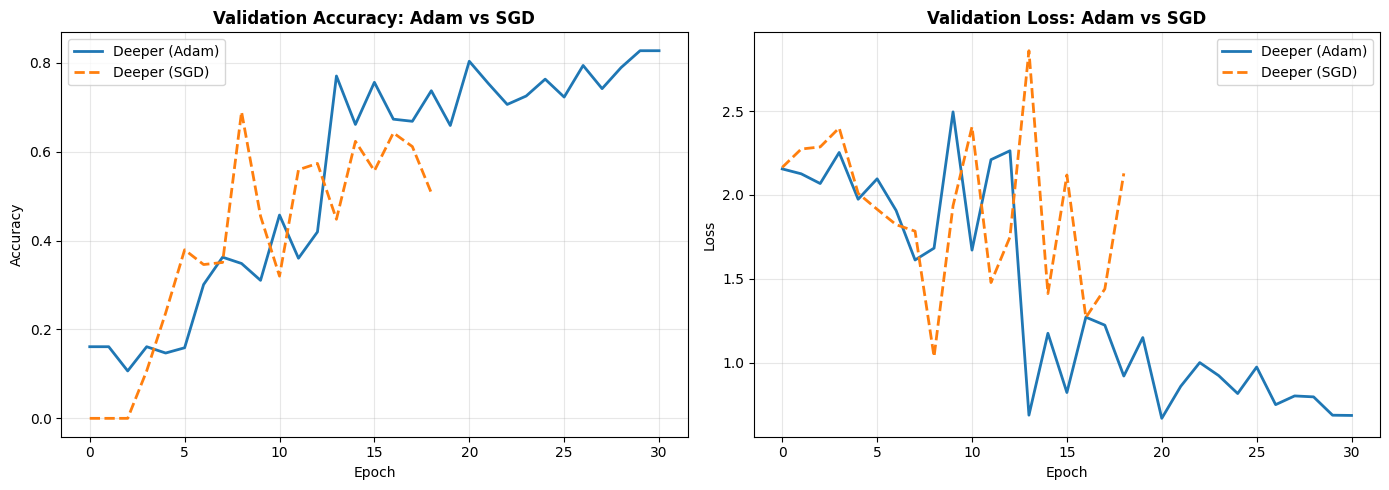

In [29]:
# ── Side-by-side loss curves: Adam vs SGD ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['val_accuracy'], label='Deeper (Adam)', linewidth=2)
axes[0].plot(sgd_history.history['val_accuracy'],    label='Deeper (SGD)',  linewidth=2, linestyle='--')
axes[0].set_title("Validation Accuracy: Adam vs SGD", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(deeper_history.history['val_loss'], label='Deeper (Adam)', linewidth=2)
axes[1].plot(sgd_history.history['val_loss'],    label='Deeper (SGD)',  linewidth=2, linestyle='--')
axes[1].set_title("Validation Loss: Adam vs SGD", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3b. Ablation Study — Removing Dropout from Deeper Architecture

In [30]:
def build_deeper_no_dropout(num_classes):
    """Deeper CNN without Dropout — to study the effect of Dropout."""
    model = keras.Sequential([
        layers.Input(shape=(128, 128, 3)),
        layers.Rescaling(1. / 255),

        layers.Conv2D(32,  (3,3), padding='same'), layers.BatchNormalization(), layers.Activation('relu'), layers.MaxPooling2D(),
        layers.Conv2D(64,  (3,3), padding='same'), layers.BatchNormalization(), layers.Activation('relu'), layers.MaxPooling2D(),
        layers.Conv2D(128, (3,3), padding='same'), layers.BatchNormalization(), layers.Activation('relu'), layers.MaxPooling2D(),
        layers.Conv2D(256, (3,3), padding='same'), layers.BatchNormalization(), layers.Activation('relu'), layers.MaxPooling2D(),
        layers.Conv2D(512, (3,3), padding='same'), layers.BatchNormalization(), layers.Activation('relu'), layers.MaxPooling2D(),
        layers.Conv2D(512, (3,3), padding='same'), layers.BatchNormalization(), layers.Activation('relu'), layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        # NO Dropout
        layers.Dense(128, activation='relu'),
        # NO Dropout
        layers.Dense(64,  activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="Deeper_NoDrop")
    return model

ablation_model = build_deeper_no_dropout(NUM_CLASSES)
ablation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ablation_history = ablation_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[EarlyStopping(monitor='val_loss', patience=8,
                              restore_best_weights=True, verbose=1)],
    class_weight=CLASS_WEIGHTS,
    verbose=1
)
print("Ablation study complete.")

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 24s 223ms/step - accuracy: 0.2771 - loss: 2.0820 - val_accuracy: 0.3981 - val_loss: 1.9956
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5429 - loss: 1.4392 - val_accuracy: 0.0000e+00 - val_loss: 1.7591
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7496 - loss: 0.9343 - val_accuracy: 0.0000e+00 - val_loss: 2.0151
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9088 - loss: 0.5090 - val_accuracy: 0.0000e+00 - val_loss: 2.5781
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9840 - loss: 0.2297 - val_accuracy: 0.0000e+00 - val_loss: 3.2357
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9970 - loss: 0.1101 - val_accuracy: 0.0000e+00 - val_loss: 3.7246
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9988 - loss: 0.0621 - val_accuracy: 0.1540 - val_loss: 2.3727
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9994 - loss: 0.0377 - va

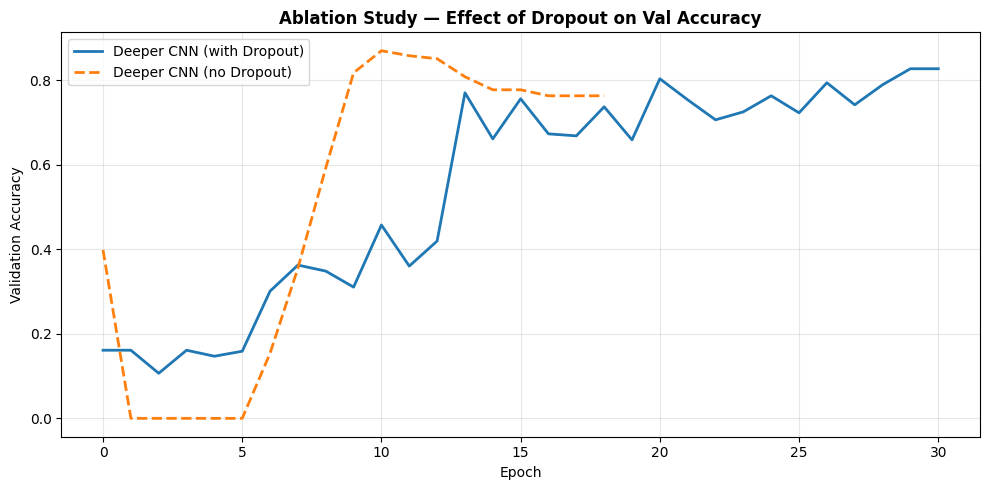


Conclusion: Dropout reduces overfitting by preventing co-adaptation of neurons.
Without Dropout, training accuracy tends to be high but val accuracy diverges (overfit).


In [31]:
# Compare val accuracy: with dropout vs without
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(deeper_history.history['val_accuracy'],   label='Deeper CNN (with Dropout)', linewidth=2)
ax.plot(ablation_history.history['val_accuracy'], label='Deeper CNN (no Dropout)',   linewidth=2, linestyle='--')
ax.set_title("Ablation Study — Effect of Dropout on Val Accuracy",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nConclusion: Dropout reduces overfitting by preventing co-adaptation of neurons.")
print("Without Dropout, training accuracy tends to be high but val accuracy diverges (overfit).")

## 3c. Comparative Summary — All Part A Models


Model                                 Test Acc      Train Time
Baseline CNN (Adam)                     54.43%           0.9 min
Deeper CNN (Adam)                       86.72%           1.1 min
Deeper CNN (SGD)                        57.55%           0.7 min


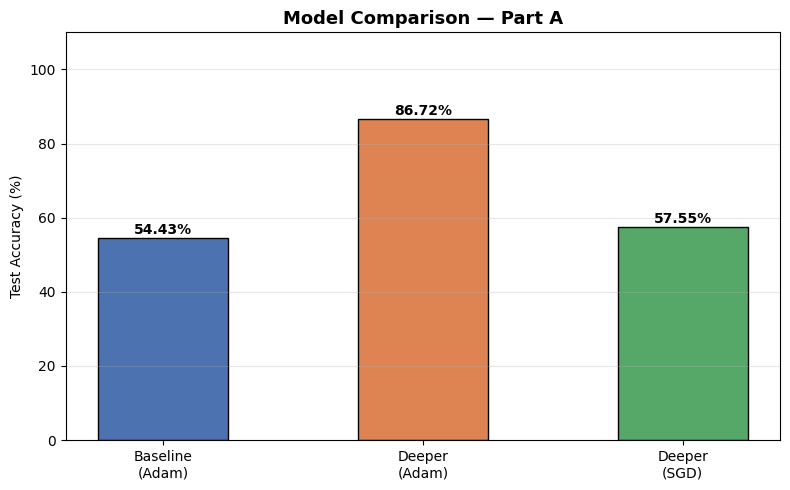

In [32]:
from sklearn.metrics import accuracy_score

def get_test_accuracy(model, test_dataset):
    y_pred = np.argmax(model.predict(test_dataset, verbose=0), axis=1)
    y_true = np.concatenate([y.numpy() for _, y in test_dataset])
    return accuracy_score(y_true, y_pred)

acc_baseline = get_test_accuracy(baseline_model, test_ds)
acc_deeper   = get_test_accuracy(deeper_model,   test_ds)
acc_sgd      = get_test_accuracy(deeper_model_sgd, test_ds)

print("\n" + "="*65)
print(f"{'Model':<35} {'Test Acc':>10} {'Train Time':>15}")
print("="*65)
print(f"{'Baseline CNN (Adam)':<35} {acc_baseline*100:>9.2f}% {BASELINE_TRAIN_TIME/60:>13.1f} min")
print(f"{'Deeper CNN (Adam)':<35} {acc_deeper*100:>9.2f}% {DEEPER_TRAIN_TIME/60:>13.1f} min")
print(f"{'Deeper CNN (SGD)':<35} {acc_sgd*100:>9.2f}% {SGD_TRAIN_TIME/60:>13.1f} min")
print("="*65)

# Bar chart
models = ['Baseline\n(Adam)', 'Deeper\n(Adam)', 'Deeper\n(SGD)']
accs   = [acc_baseline, acc_deeper, acc_sgd]
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, [a * 100 for a in accs], color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{acc*100:.2f}%", ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 110)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Model Comparison — Part A", fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part B — Transfer Learning with MobileNetV2

We leverage **MobileNetV2** pre-trained on ImageNet. Transfer learning proceeds in two phases:

1. **Feature Extraction** — Freeze the convolutional base; train only the new classifier head.
2. **Fine-Tuning** — Unfreeze the top layers of the base; retrain end-to-end at a very low learning rate.

> MobileNetV2 requires input images of **224×224** and pixel values preprocessed with `preprocess_input`  
> (scaling to −1 … +1 as expected by the model).

In [33]:
# Recompute class weights from folder counts for TL pipeline
all_labels_tl = np.array(all_labels)   # reuse from the cell above (same train_dir)
class_weights_tl = dict(enumerate(
    compute_class_weight('balanced', classes=np.unique(all_labels_tl), y=all_labels_tl)
))
print("TL class weights ready.")

TL class weights ready.


In [37]:
# ── Load MobileNetV2 base (without top classifier) ────────────────────────────
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT_TL, IMG_WIDTH_TL, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # Freeze all layers for Feature Extraction phase

print(f"Base model layers : {len(base_model.layers)}")
print(f"Trainable params  : {base_model.count_params():,} (all frozen)")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers : 154
Trainable params  : 2,257,984 (all frozen)


In [38]:
# ── Build the full transfer learning model ─────────────────────────────────────
inputs  = keras.Input(shape=(IMG_HEIGHT_TL, IMG_WIDTH_TL, 3))
x       = base_model(inputs, training=False)   # training=False → BN layers in inference mode
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_tl = Model(inputs, outputs, name="MobileNetV2_Transfer")
model_tl.summary()

Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,977 (9.99 MB)

 Trainable params: 361,993 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Phase 1 — Feature Extraction (Frozen Base)

In [41]:
IMG_HEIGHT_TL = 128
IMG_WIDTH_TL = 128

# Re-create raw datasets with MobileNetV2's expected input size
# Training split
print("Creating raw datasets for Transfer Learning...")
train_ds_raw_tl = tf.keras.preprocessing.image_dataset_from_directory(
    CLEAN_TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT_TL, IMG_WIDTH_TL),
    interpolation='bilinear',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Validation split
val_ds_raw_tl = tf.keras.preprocessing.image_dataset_from_directory(
    CLEAN_TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT_TL, IMG_WIDTH_TL),
    interpolation='bilinear',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Test set
test_ds_raw_tl = tf.keras.preprocessing.image_dataset_from_directory(
    CLEAN_TEST_DIR,
    image_size=(IMG_HEIGHT_TL, IMG_WIDTH_TL),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Preprocessing function for MobileNetV2
def preprocess_for_mobilenet(image, label):
    # Apply MobileNetV2 specific preprocessing: scale pixels to [-1, 1]
    image = mobilenet_preprocess(image)
    return image, label

# Build final pipeline functions for TL
def make_train_pipeline_tl(ds):
    return (
        ds
        .map(lambda x, y: (data_augmentation(x, training=True), y),
             num_parallel_calls=AUTOTUNE)
        .map(preprocess_for_mobilenet, num_parallel_calls=AUTOTUNE)
        .cache()
        .prefetch(AUTOTUNE)
    )

def make_eval_pipeline_tl(ds):
    return (
        ds
        .map(preprocess_for_mobilenet, num_parallel_calls=AUTOTUNE)
        .cache()
        .prefetch(AUTOTUNE)
    )

train_ds_tl = make_train_pipeline_tl(train_ds_raw_tl)
val_ds_tl   = make_eval_pipeline_tl(val_ds_raw_tl)
test_ds_tl  = make_eval_pipeline_tl(test_ds_raw_tl) # Also define test_ds_tl for later use

print(f"TL Training batches  : {len(train_ds_tl)}")
print(f"TL Validation batches: {len(val_ds_tl)}")
print(f"TL Test batches      : {len(test_ds_tl)}")

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es_tl   = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
rlr_tl  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)

print("Phase 1: Feature Extraction...")
tl_start = time.time()

history_tl_fe = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=20,
    callbacks=[es_tl, rlr_tl],
    class_weight=class_weights_tl,
    verbose=1
)

TL_FE_TIME = time.time() - tl_start
print(f"\nPhase 1 training time: {TL_FE_TIME:.1f} s ({TL_FE_TIME/60:.1f} min)")

Creating raw datasets for Transfer Learning...
Found 2111 files belonging to 9 classes.
Using 1689 files for training.
Found 2111 files belonging to 9 classes.
Using 422 files for validation.
Found 384 files belonging to 9 classes.
TL Training batches  : 53
TL Validation batches: 14
TL Test batches      : 12
Phase 1: Feature Extraction...
Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.5844 - loss: 1.2971 - val_accuracy: 0.6919 - val_loss: 0.7713 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8792 - loss: 0.4165 - val_accuracy: 0.8555 - val_loss: 0.4893 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9532 - loss: 0.1895 - val_accuracy: 0.8886 - val_loss: 0.2889 - learning_rate: 0.0010
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9757 - loss: 0.0924 - val_accuracy: 0.9479 - val_loss: 0.1710 - learning_rate: 0.0010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - ac

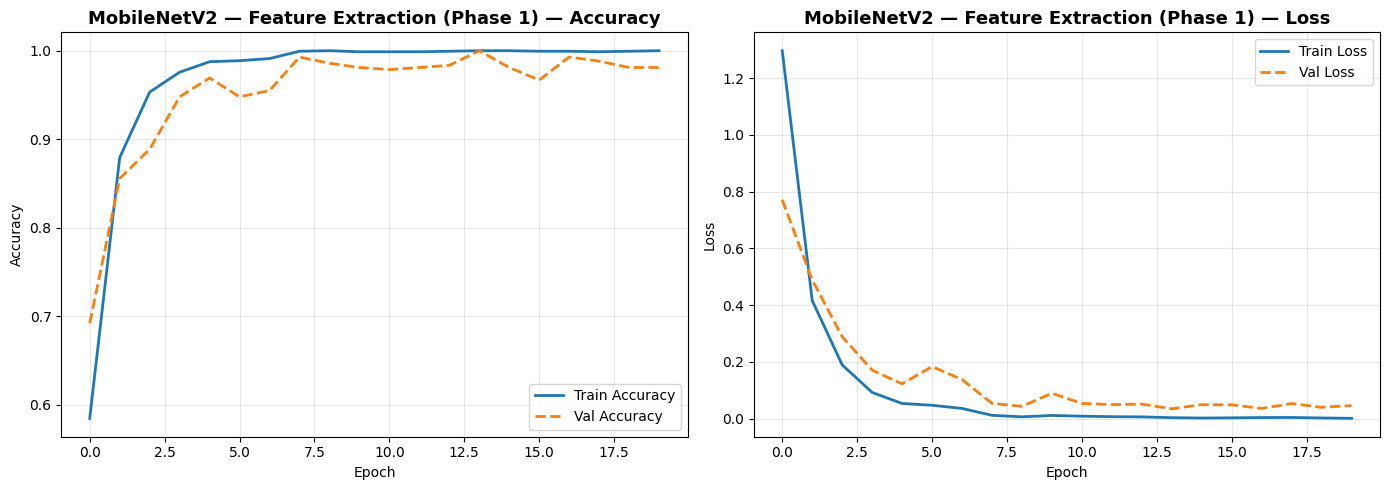

In [42]:
plot_history(history_tl_fe, "MobileNetV2 — Feature Extraction (Phase 1)")

## Phase 2 — Fine-Tuning (Unfreeze Top Layers)

In [43]:
# Unfreeze the top 30 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable base layers after unfreeze: {trainable_count}/{len(base_model.layers)}")

# Very low learning rate to avoid destroying learned features
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es_ft  = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
rlr_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-8, verbose=1)

print("Phase 2: Fine-Tuning...")
ft_start = time.time()

history_tl_ft = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=20,
    callbacks=[es_ft, rlr_ft],
    class_weight=class_weights_tl,
    verbose=1
)

TL_FT_TIME = time.time() - ft_start
print(f"\nPhase 2 training time: {TL_FT_TIME:.1f} s ({TL_FT_TIME/60:.1f} min)")

Trainable base layers after unfreeze: 30/154
Phase 2: Fine-Tuning...
Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.8774 - loss: 0.3685 - val_accuracy: 1.0000 - val_loss: 0.0297 - learning_rate: 1.0000e-05
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 56s 14ms/step - accuracy: 0.9426 - loss: 0.1775 - val_accuracy: 1.0000 - val_loss: 0.0301 - learning_rate: 1.0000e-05
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9651 - loss: 0.1138 - val_accuracy: 1.0000 - val_loss: 0.0319 - learning_rate: 1.0000e-05
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9846 - loss: 0.0701 - val_accuracy: 1.0000 - val_loss: 0.0296 - learning_rate: 1.0000e-05
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9882 - loss: 0.0497
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9834 - loss: 0.0561 - val_accuracy: 1.0000 - val_loss: 0.0317 - learning_rate: 1.0000e-05
Epoch 

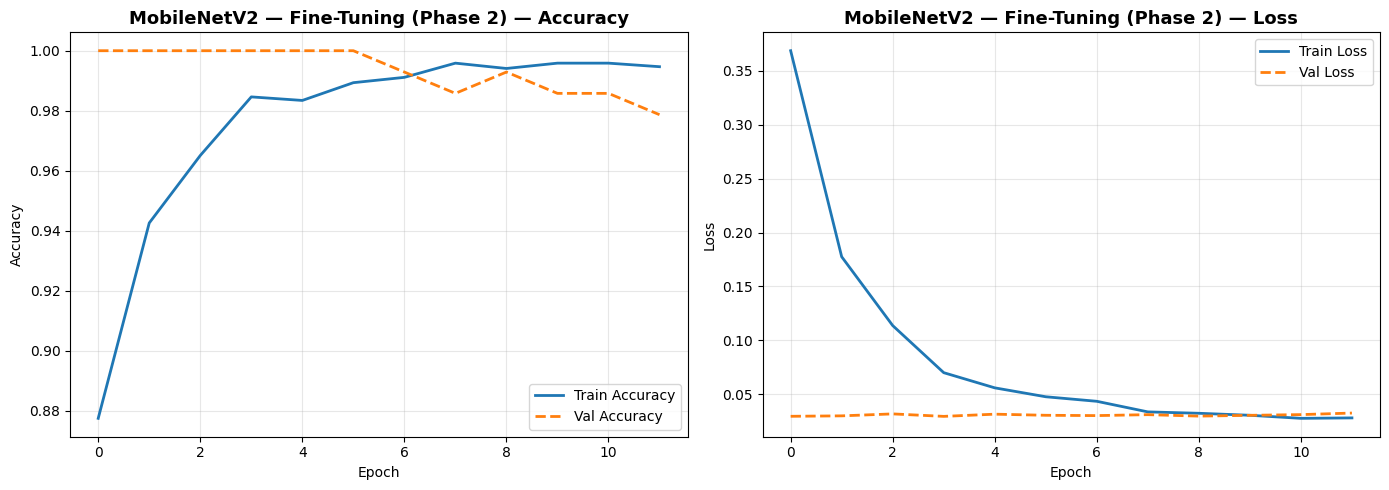

In [44]:
plot_history(history_tl_ft, "MobileNetV2 — Fine-Tuning (Phase 2)")


  Evaluation Results — MobileNetV2 (Transfer Learning)
              precision    recall  f1-score   support

      aphids       0.94      1.00      0.97        44
    armyworm       1.00      0.88      0.94        43
      beetle       1.00      0.98      0.99        50
    bollworm       0.95      0.97      0.96        36
 grasshopper       0.96      1.00      0.98        46
       mites       0.98      1.00      0.99        42
    mosquito       1.00      1.00      1.00        50
      sawfly       0.97      0.92      0.94        37
  stem_borer       0.95      0.97      0.96        36

    accuracy                           0.97       384
   macro avg       0.97      0.97      0.97       384
weighted avg       0.97      0.97      0.97       384



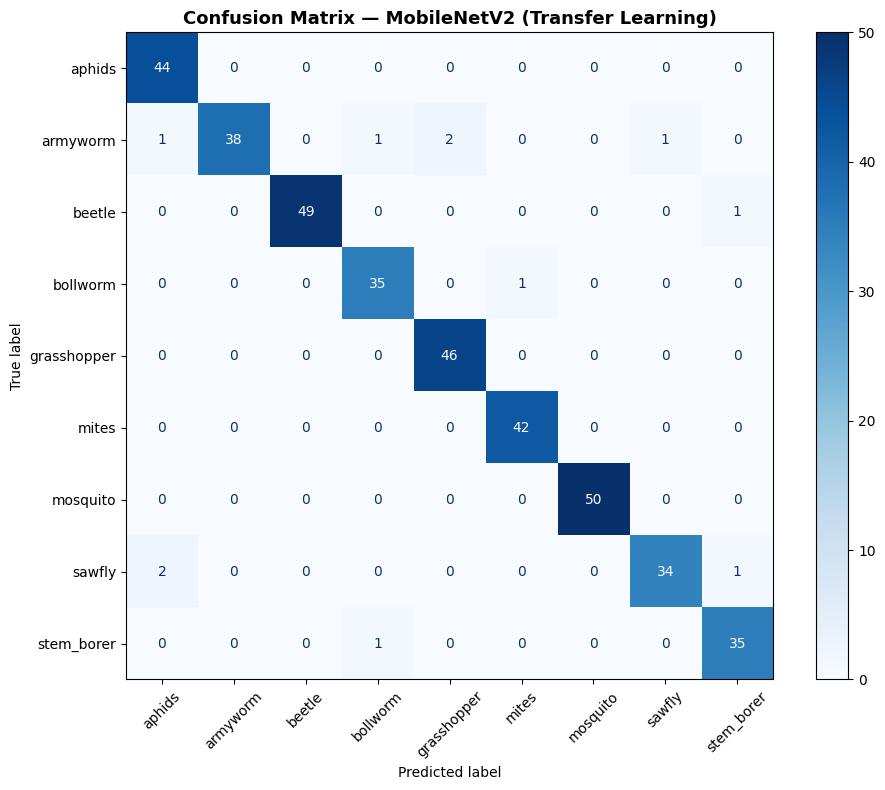

In [45]:
y_true_tl, y_pred_tl = evaluate_model(model_tl, test_ds_tl, CLASS_NAMES,
                                        "MobileNetV2 (Transfer Learning)")

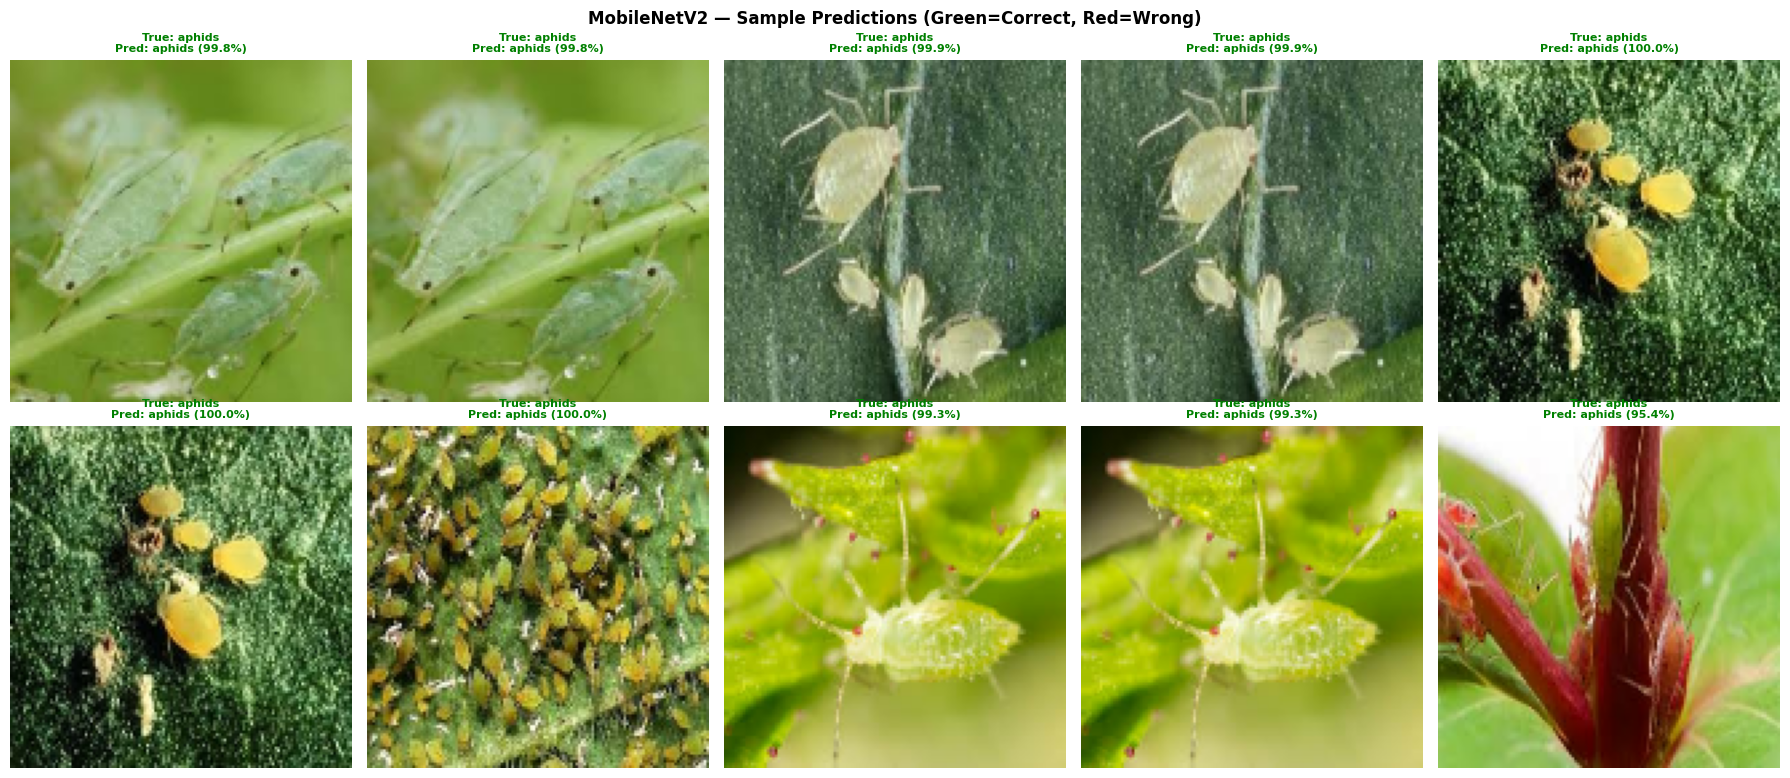

In [46]:
# ── Sample predictions from the TL model ──────────────────────────────────────
sample_images_raw, sample_labels_raw = next(iter(test_ds_raw))
sample_input = mobilenet_preprocess(tf.cast(sample_images_raw, tf.float32))
tl_preds  = model_tl.predict(sample_input, verbose=0)
tl_pred_classes = np.argmax(tl_preds, axis=1)
tl_confs        = np.max(tl_preds, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    if i >= sample_images_raw.shape[0]:
        ax.axis('off'); continue
    ax.imshow(sample_images_raw[i].numpy().astype('uint8'))
    true_cls = CLASS_NAMES[sample_labels_raw[i]]
    pred_cls = CLASS_NAMES[tl_pred_classes[i]]
    color = 'green' if true_cls == pred_cls else 'red'
    ax.set_title(f"True: {true_cls}\nPred: {pred_cls} ({tl_confs[i]*100:.1f}%)",
                 color=color, fontsize=8, fontweight='bold')
    ax.axis('off')

plt.suptitle("MobileNetV2 — Sample Predictions (Green=Correct, Red=Wrong)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Final Comparison — All Models


Model                                 Test Acc           Train Time
Baseline CNN (Adam)                     54.43%                0.9 min
Deeper CNN (Adam)                       86.72%                1.1 min
Deeper CNN (SGD)                        57.55%                0.7 min
MobileNetV2 (TL+FineTune)               97.14%                4.8 min


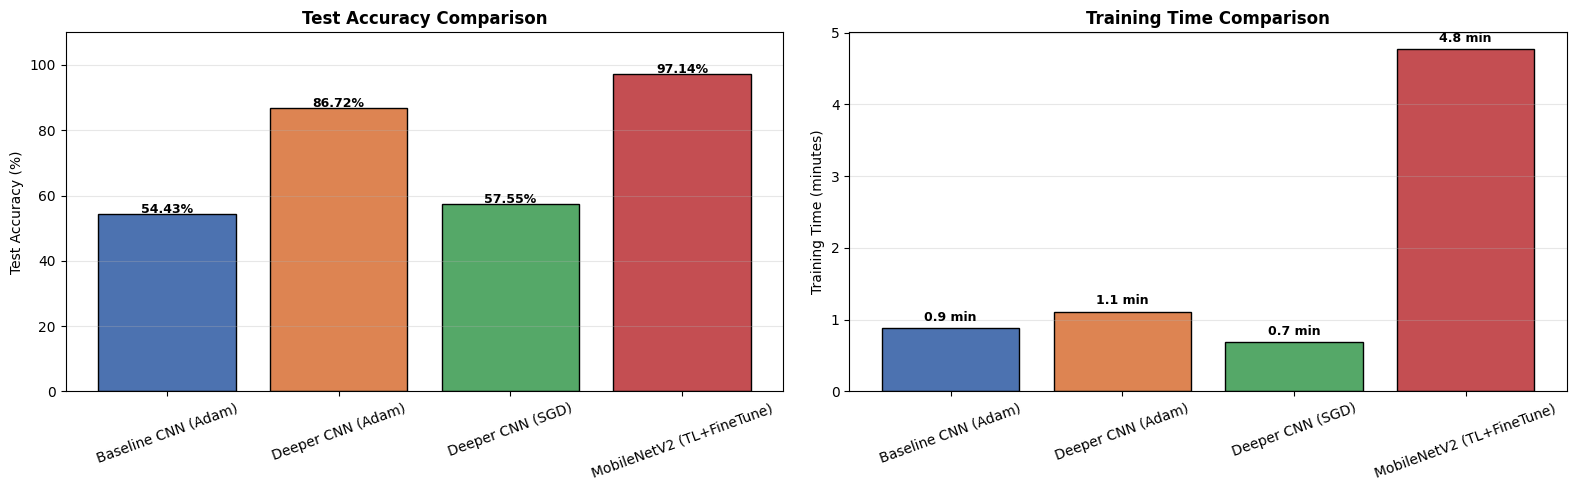

In [47]:
acc_tl = get_test_accuracy(model_tl, test_ds_tl)

summary = {
    "Baseline CNN (Adam)":        (acc_baseline, BASELINE_TRAIN_TIME),
    "Deeper CNN (Adam)":          (acc_deeper,   DEEPER_TRAIN_TIME),
    "Deeper CNN (SGD)":           (acc_sgd,      SGD_TRAIN_TIME),
    "MobileNetV2 (TL+FineTune)": (acc_tl,       TL_FE_TIME + TL_FT_TIME),
}

print("\n" + "="*70)
print(f"{'Model':<35} {'Test Acc':>10} {'Train Time':>20}")
print("="*70)
for name, (acc, t) in summary.items():
    print(f"{name:<35} {acc*100:>9.2f}% {t/60:>18.1f} min")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

names  = list(summary.keys())
accs   = [v[0] * 100 for v in summary.values()]
times  = [v[1] / 60  for v in summary.values()]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

bars0 = axes[0].bar(names, accs, color=colors, edgecolor='black')
for bar, a in zip(bars0, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{a:.2f}%", ha='center', fontweight='bold', fontsize=9)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("Test Accuracy (%)")
axes[0].set_title("Test Accuracy Comparison", fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

bars1 = axes[1].bar(names, times, color=colors, edgecolor='black')
for bar, t in zip(bars1, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{t:.1f} min", ha='center', fontweight='bold', fontsize=9)
axes[1].set_ylabel("Training Time (minutes)")
axes[1].set_title("Training Time Comparison", fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
# Conclusion

## Key Observations

| Finding | Detail |
|---------|--------|
| **Deeper > Baseline** | Adding more Conv blocks and regularization (BN + Dropout) improved generalisation. |
| **Adam > SGD** | Adam converged faster and reached higher accuracy; SGD with momentum is competitive but slower. |
| **Dropout matters** | The ablation study confirmed that removing Dropout leads to overfitting (train acc ≫ val acc). |
| **Transfer Learning wins** | MobileNetV2 fine-tuned on ImageNet weights outperforms all scratch-trained models, especially given the limited dataset size. |
| **Trade-offs** | Transfer learning requires less training data but needs care during fine-tuning (very low lr to avoid catastrophic forgetting). |

## Hardware
All experiments were run on **Google Colab** with **GPU acceleration** and mixed-precision (`float16`) enabled.

## Future Work
- Experiment with EfficientNet or ConvNeXt as alternative backbones.
- Apply test-time augmentation (TTA) to further improve inference accuracy.
- Collect more labelled data for minority classes (mites, stem_borer) to address class imbalance.